In [8]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

In [9]:
def delta(t, h, theta, t0, n_kicks):
    func = 0.0
    for k in range(1, n_kicks + 1):
        func += (theta/2) / np.sqrt(2*np.pi*h**2) * np.exp(-(t - k*t0)**2/(2*h**2))
    return func

def get_tau_r(N):
    H0, w, v, psi0, _ = get_scar_ham(N)
    amp = np.array([s.overlap(psi0) for s in v])
    ts = np.linspace(2, 15, 20000)
    f = np.abs((np.abs(amp)**2) @ np.exp(-1j * np.outer(w, ts)))**2
    return ts[np.argmax(f)]

In [10]:
N = 10
wd = 0.6366896896896898
wm = 1.0
tau_r = get_tau_r(N)
tau = tau_r / 2
n_cycles = 10 # must be EVEN
t_max = n_cycles * tau
h = 0.01
n_t = int(np.ceil(t_max / (h/3)))
tlist = np.linspace(0, t_max, n_t, endpoint=False)
reals = 1
dis = 0.0

tau_r = get_tau_r(N)
print(f"tau_r = {tau_r:.4f}")

tau_r = 9.9083


In [11]:
freq  = np.fft.fftfreq(n_t, d=tlist[1]-tlist[0])
k_sub = n_cycles // 2
assert np.isclose(freq[k_sub], 1/(2*tau)), (freq[k_sub], 1/(2*tau))

thetalist = np.linspace(0, 2*np.pi, 100, endpoint=False)

H0_clean, _, _, psi0, basisList = get_scar_ham(N)
H1, driveWeights = get_scar_H1_no_z2(N, basisList)

f2 = np.zeros(len(thetalist))
spectra = np.zeros((len(thetalist), n_t))

for i, theta in enumerate(thetalist):
    args = {"h": h, "theta": theta, "t0": tau, "n_kicks": n_cycles}

    full_scar = 0
    for _ in range(reals):
        H0, ev, es = get_dis_scar_ham(H0_clean, N, basisList, ham_disorder=[0, 0, 0])
        bandwidth = ev[-1] - ev[0]
        H = qt.QobjEvo([H0, [H1, delta]], args=args)
        psi_t = qt.sesolve(H, psi0, tlist, e_ops=[H0],
                           options={"max_step": h/5, "atol": 1e-12, "rtol": 1e-10})
        full_scar = full_scar + np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth
    x = full_scar / reals

    S = np.fft.fft(x - x.mean())
    spectra[i] = np.abs(S)
    f2[i] = np.abs(S[k_sub])**2

In [12]:
f2_frac = f2 / (spectra**2).sum(axis=1)
f2_rel = f2 / f2[np.argmin(np.abs(thetalist - np.pi))]

C:\Users\idden\AppData\Local\Temp\ipykernel_5532\4032454586.py:1: RuntimeWarning: invalid value encountered in divide
  f2_frac = f2 / (spectra**2).sum(axis=1)


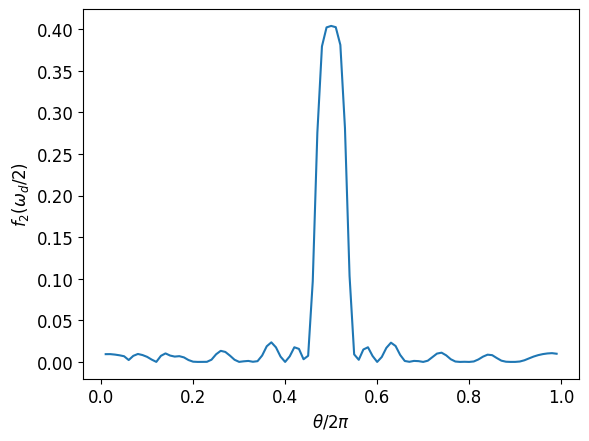

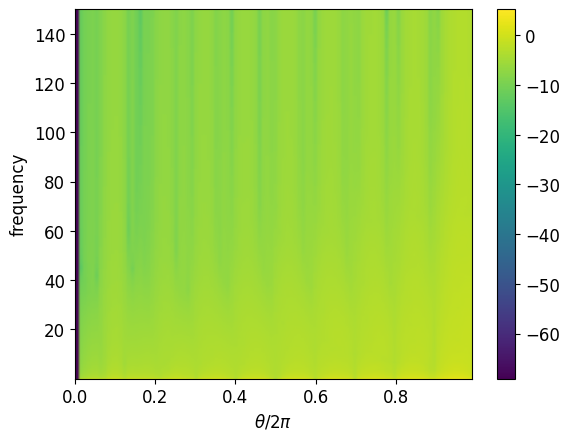

In [13]:
plt.plot(thetalist/(2*np.pi), f2_frac)
plt.xlabel(r"$\theta/2\pi$"); plt.ylabel(r"$f_2(\omega_d/2)$")
plt.show()

pos = freq > 0
plt.imshow(np.log(spectra[:, pos].T + 1e-30), aspect='auto', origin='lower',
           extent=[thetalist[0]/(2*np.pi), thetalist[-1]/(2*np.pi),
                   freq[pos].min(), freq[pos].max()])
plt.xlabel(r"$\theta/2\pi$"); plt.ylabel("frequency")
plt.colorbar(); plt.show()